In [2]:
import pandas as pd
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.model_selection import train_test_split

from sklearn.naive_bayes import MultinomialNB

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

from imblearn.over_sampling import SMOTE

In [3]:
from google.colab import files
uploaded = files.upload()

Saving dataset_Analyse_des_sentiments_clean.json to dataset_Analyse_des_sentiments_clean.json


In [4]:
df = pd.read_json('dataset_Analyse_des_sentiments_clean.json')

print(df.shape)

df.head()

(500, 12)


,Date,Auteur,Note,Version,Titre,Commentaire,Votes,satisfaction,YearMonth,word_count,clean_commentaire,clean_Titre
0,2025-09-23 13:06:00,Svent's,3,2.1.0,Bonne app mais…,"Belle interface sur iPhone, il manque juste la...",0,neutral,2025-09,34,belle interface sur iphone manque juste foncti...,bonne app mais
1,2025-09-24 06:53:00,mikael357,2,2.1.0,Pas assez intuitive,Je trouve que la nouvelle appli n’est vraiment...,0,negative,2025-09,57,trouve que nouvelle appli est vraiment pas int...,pas assez intuitive
2,2025-09-26 12:47:00,tomusspupuce,5,2.1.0,Très bon produit,Instantanément. Intelligent. Connecté.,0,positive,2025-09,3,instantanement intelligent connecte,tres bon produit
3,2025-09-27 11:24:00,Joueur Curling,5,2.1.0,Parfait,"Très utile, plus besoin de penser à ce qu’il f...",0,positive,2025-09,19,tres utile plus besoin penser faut faire surto...,parfait
4,2025-09-28 00:39:00,Amonyme,3,2.1.0,Arrêtez la mise à jour intempestive svp,L’app est simple et pratique mais il y a une s...,0,neutral,2025-09,42,app est simple pratique mais une sorte big qui...,arretez mise jour intempestive svp


# **TF-IDF**

In [5]:
df["full_text"] = (
    df["clean_Titre"].astype(str)
    + " "
    + df["clean_commentaire"].astype(str)
)
vectorizer = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1,2)
)

X = vectorizer.fit_transform(
    df["full_text"]
)

y = df["satisfaction"]

# **TRAIN / TEST SPLIT**

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


# **NAIVE BAYES BASELINE**

In [7]:
nb = MultinomialNB()

nb.fit(X_train, y_train)

y_pred_nb = nb.predict(X_test)

print("===== NAIVE BAYES =====")

print(classification_report(y_test, y_pred_nb))

===== NAIVE BAYES =====
              precision    recall  f1-score   support

    negative       0.59      0.65      0.62        37
     neutral       0.00      0.00      0.00        21
    positive       0.58      0.81      0.67        42

    accuracy                           0.58       100
   macro avg       0.39      0.49      0.43       100
weighted avg       0.46      0.58      0.51       100



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


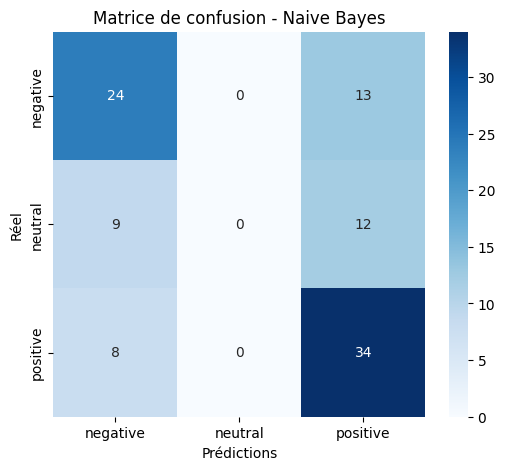

In [8]:
cm = confusion_matrix(y_test, y_pred_nb)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=nb.classes_,
    yticklabels=nb.classes_
)

plt.xlabel('Prédictions')
plt.ylabel('Réel')

plt.title('Matrice de confusion - Naive Bayes')

plt.show()

# **Naive Bayes+Class weight**

In [9]:
# Calcul des poids
sample_weights = compute_sample_weight(
    class_weight='balanced',
    y=y_train
)

# Modèle Naive Bayes
nb_weighted = MultinomialNB()

# Entraînement avec poids
nb_weighted.fit(
    X_train,
    y_train,
    sample_weight=sample_weights
)

# Prédictions
y_pred_nb_weighted = nb_weighted.predict(X_test)

print("===== NAIVE BAYES + CLASS WEIGHT =====")

print(classification_report(
    y_test,
    y_pred_nb_weighted
))

===== NAIVE BAYES + CLASS WEIGHT =====
              precision    recall  f1-score   support

    negative       0.61      0.68      0.64        37
     neutral       0.32      0.33      0.33        21
    positive       0.65      0.57      0.61        42

    accuracy                           0.56       100
   macro avg       0.53      0.53      0.52       100
weighted avg       0.56      0.56      0.56       100



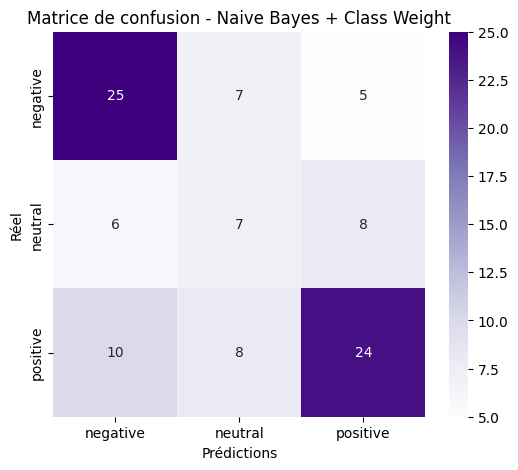

In [10]:
from sklearn.metrics import confusion_matrix

# Matrice de confusion
cm_nb_weighted = confusion_matrix(
    y_test,
    y_pred_nb_weighted
)

# Affichage
plt.figure(figsize=(6,5))

sns.heatmap(
    cm_nb_weighted,
    annot=True,
    fmt='d',
    cmap='Purples',
    xticklabels=nb_weighted.classes_,
    yticklabels=nb_weighted.classes_
)

plt.xlabel('Prédictions')
plt.ylabel('Réel')

plt.title('Matrice de confusion - Naive Bayes + Class Weight')

plt.show()

# **SMOTE**


In [11]:
smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train,
    y_train
)

# **NAIVE BAYES + SMOTE**

In [12]:
nb_smote = MultinomialNB()

nb_smote.fit(X_train_smote, y_train_smote)

y_pred_nb_smote = nb_smote.predict(X_test)

print("===== NAIVE BAYES + SMOTE =====")

print(classification_report(y_test, y_pred_nb_smote))

===== NAIVE BAYES + SMOTE =====
              precision    recall  f1-score   support

    negative       0.66      0.68      0.67        37
     neutral       0.32      0.33      0.33        21
    positive       0.60      0.57      0.59        42

    accuracy                           0.56       100
   macro avg       0.53      0.53      0.53       100
weighted avg       0.56      0.56      0.56       100



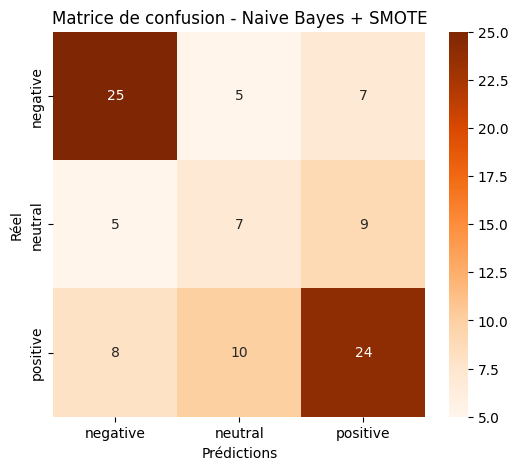

In [13]:
cm_smote = confusion_matrix(
    y_test,
    y_pred_nb_smote
)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm_smote,
    annot=True,
    fmt='d',
    cmap='Oranges',
    xticklabels=nb_smote.classes_,
    yticklabels=nb_smote.classes_
)

plt.xlabel('Prédictions')
plt.ylabel('Réel')

plt.title('Matrice de confusion - Naive Bayes + SMOTE')

plt.show()


# **TABLEAU COMPARATIF**

In [14]:
results_nb = pd.DataFrame({

    'Model': [
        'Naive Bayes',
        'Naive Bayes + Class Weight',
        'Naive Bayes + SMOTE'
    ],

    'Accuracy': [
        accuracy_score(y_test, y_pred_nb),
        accuracy_score(y_test, y_pred_nb_weighted),
        accuracy_score(y_test, y_pred_nb_smote)
    ],

    'Precision': [
        precision_score(
            y_test,
            y_pred_nb,
            average='weighted'
        ),

        precision_score(
            y_test,
            y_pred_nb_weighted,
            average='weighted'
        ),

        precision_score(
            y_test,
            y_pred_nb_smote,
            average='weighted'
        )
    ],

    'Recall': [
        recall_score(
            y_test,
            y_pred_nb,
            average='weighted'
        ),

        recall_score(
            y_test,
            y_pred_nb_weighted,
            average='weighted'
        ),

        recall_score(
            y_test,
            y_pred_nb_smote,
            average='weighted'
        )
    ],

    'F1-score': [
        f1_score(
            y_test,
            y_pred_nb,
            average='weighted'
        ),

        f1_score(
            y_test,
            y_pred_nb_weighted,
            average='weighted'
        ),

        f1_score(
            y_test,
            y_pred_nb_smote,
            average='weighted'
        )
    ]
})

print(results_nb)

                        Model  Accuracy  Precision  Recall  F1-score
0                 Naive Bayes      0.58   0.458619    0.58  0.510465
1  Naive Bayes + Class Weight      0.56   0.564860    0.56  0.560741
2         Naive Bayes + SMOTE      0.56   0.562239    0.56  0.560892


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
